In [23]:
import numpy as np 
import matplotlib.pyplot as plt

In [25]:
def generate_data(n = 80, noise = 0.3, seed = 0):
    rng = np.random.default_rng(seed)
    X= np.linspace(-3, 3, n)
    y_true = np.sin(X)
    y = y_true + noise * rng.normal(size=n)
    return X.reshape(-1, 1), y, y_true

In [27]:
def gaussian_weights(x0, X, tau):
    diff = X - x0
    return np.exp(-(diff ** 2) / (2*tau **2))

In [29]:
def lwlr_predict_point(x0, X, y, tau):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    x0_b = np.array([1.0, x0])
    w = gaussian_weights(x0, X, tau).flatten()
    W = np.diag(w)
    Xt_W = X_b.T @W
    theta = np.linalg.pinv(Xt_W @ X_b) @ Xt_W @ y
    return x0_b @ theta 

In [31]:
def lwlr_predict(X_query, X_train, y_train, tau):
    return np.array([
        lwlr_predict_point(x0, X_train, y_train, tau)
        for x0 in X_query.flatten()
    ])

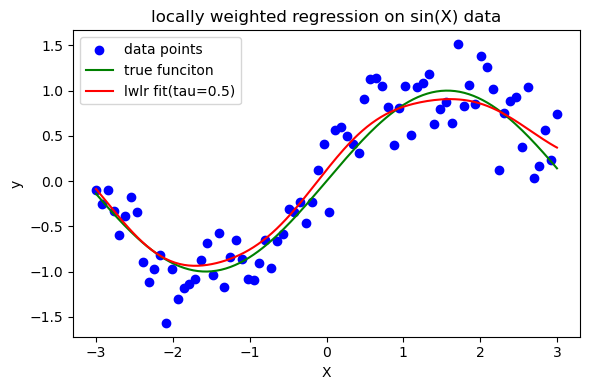

In [33]:
if __name__ == "__main__":
    X, y, y_true = generate_data()
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    tau = 0.5
    y_pred = lwlr_predict(X_plot, X, y, tau)

    plt.figure(figsize=(6, 4))
    plt.scatter(X, y, color= 'blue', label = 'data points')
    plt.plot(X_plot, np.sin(X_plot), color = 'green', label = 'true funciton')
    plt.plot(X_plot, y_pred, color='red', label = f'lwlr fit(tau={tau})')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.title('locally weighted regression on sin(X) data')
    plt.tight_layout()
    plt.show()